# Notebook 07 — Deep Learning with PyTorch
**Regression** → Predict WQI
**Classification** → Predict Water Quality Category

### Why Deep Learning?
- All previous models (Linear, Tree, SVM) are **shallow** — one or two transformation
steps
- Neural Networks stack **multiple layers** of transformations
- Each layer learns increasingly abstract patterns from the data
- With enough layers and neurons, can approximate **any function**
- PyTorch gives full control over architecture, loss, optimizer

### Architecture — Multi Layer Perceptron (MLP):
Input Layer  → (number of features)
Hidden Layer 1 → neurons + ReLU activation
Hidden Layer 2 → neurons + ReLU activation
Hidden Layer 3 → neurons + ReLU activation
Output Layer → 1 neuron (regression) or 5 neurons (classification)

In [3]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')                  

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
  r2_score, mean_squared_error, mean_absolute_error,
  accuracy_score, f1_score, classification_report, confusion_matrix
)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
print("PyTorch version:", torch.__version__)

Using device: cpu
PyTorch version: 2.10.0


In [4]:
with open('processed_data.pkl', 'rb') as f:
  data = pickle.load(f)

X_train       = data['X_train']
X_test        = data['X_test']
y_reg_train   = data['y_reg_train']
y_reg_test    = data['y_reg_test']
y_clf_train   = data['y_clf_train']
y_clf_test    = data['y_clf_test']
le            = data['label_encoder']
feature_names = data['feature_names']

n_features = X_train.shape[1]
n_classes  = len(le.classes_)

print("Train size  :", X_train.shape)
print("Test  size  :", X_test.shape)
print("Features    :", n_features)
print("Classes     :", n_classes, "→", list(le.classes_))

Train size  : (15223, 30)
Test  size  : (3806, 30)
Features    : 30
Classes     : 5 → ['Excellent', 'Good', 'Poor', 'Unsuitable for Drinking', 'Very Poor yet Drinkable']


In [5]:
#(Convert to PyTorch Tensors)

# Convert to numpy first then to tensors
X_train_t     = torch.tensor(X_train.values,        dtype=torch.float32).to(device)
X_test_t      = torch.tensor(X_test.values,         dtype=torch.float32).to(device)
y_reg_train_t = torch.tensor(y_reg_train.values,    dtype=torch.float32).to(device)
y_reg_test_t  = torch.tensor(y_reg_test.values,     dtype=torch.float32).to(device)
y_clf_train_t = torch.tensor(y_clf_train.values,    dtype=torch.long).to(device)
y_clf_test_t  = torch.tensor(y_clf_test.values,     dtype=torch.long).to(device)

# Create DataLoaders for batch training
BATCH_SIZE = 64

reg_train_loader = DataLoader(
  TensorDataset(X_train_t, y_reg_train_t),
  batch_size=BATCH_SIZE, shuffle=True            
)

clf_train_loader = DataLoader(
  TensorDataset(X_train_t, y_clf_train_t),
  batch_size=BATCH_SIZE, shuffle=True
)

print("Tensors created successfully")
print(f"Batches per epoch: {len(reg_train_loader)}")

Tensors created successfully
Batches per epoch: 238


## Part 1 — Regression Network (Predict WQI)

### Architecture:                                  
Input(n_features) → Dense(128) → ReLU → Dropout(0.3)
               → Dense(64)  → ReLU → Dropout(0.3)
               → Dense(32)  → ReLU
               → Dense(1)   → Output (WQI value)

### Key concepts:
- **ReLU** → activation function: output = max(0, x) — adds non-linearity
- **Dropout** → randomly zeros out neurons during training — prevents overfitting
- **Loss function** → MSELoss (Mean Squared Error) for regression
- **Optimizer** → Adam — adaptive learning rate, most popular choice

In [6]:
#(Define Regression Network)

class WQIRegressor(nn.Module):
  def __init__(self, input_dim):
      super(WQIRegressor, self).__init__()
      self.network = nn.Sequential(
          nn.Linear(input_dim, 128),
          nn.ReLU(),
          nn.Dropout(0.3),                       
          nn.Linear(128, 64),
          nn.ReLU(),
          nn.Dropout(0.3),
          nn.Linear(64, 32),
          nn.ReLU(),
          nn.Linear(32, 1)                       
      )

  def forward(self, x):
      return self.network(x).squeeze()

reg_model = WQIRegressor(n_features).to(device)    
print(reg_model)
print(f"\nTotal parameters: {sum(p.numel() for p in reg_model.parameters()):,}")



WQIRegressor(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 14,337


In [7]:
#(Train Regression Network)

EPOCHS      = 100                                  
LR          = 0.001

criterion_reg = nn.MSELoss()
optimizer_reg = optim.Adam(reg_model.parameters(), lr=LR)

train_losses = []                                  
test_losses  = []

for epoch in range(EPOCHS):
  # Training phase
  reg_model.train()
  batch_losses = []
  for X_batch, y_batch in reg_train_loader:
      optimizer_reg.zero_grad()
      predictions = reg_model(X_batch)
      loss = criterion_reg(predictions, y_batch)
      loss.backward()
      optimizer_reg.step()                       
      batch_losses.append(loss.item())

  train_loss = np.mean(batch_losses)

  # Evaluation phase
  reg_model.eval()                               
  with torch.no_grad():
      test_preds = reg_model(X_test_t)
      test_loss  = criterion_reg(test_preds, y_reg_test_t).item()

  train_losses.append(train_loss)
  test_losses.append(test_loss)

  if (epoch + 1) % 10 == 0:
      print(f"Epoch [{epoch+1:3d}/{EPOCHS}]  "
            f"Train Loss: {train_loss:.4f}  "
            f"Test Loss: {test_loss:.4f}")



Epoch [ 10/100]  Train Loss: 3020.9854  Test Loss: 821.9925
Epoch [ 20/100]  Train Loss: 2517.6375  Test Loss: 358.7093
Epoch [ 30/100]  Train Loss: 2783.5623  Test Loss: 250.4914
Epoch [ 40/100]  Train Loss: 2219.5057  Test Loss: 270.8731
Epoch [ 50/100]  Train Loss: 2464.1752  Test Loss: 253.4393
Epoch [ 60/100]  Train Loss: 2289.0481  Test Loss: 704.1008
Epoch [ 70/100]  Train Loss: 2254.8838  Test Loss: 350.9064
Epoch [ 80/100]  Train Loss: 2196.9033  Test Loss: 599.9195
Epoch [ 90/100]  Train Loss: 2085.4521  Test Loss: 237.3774
Epoch [100/100]  Train Loss: 1892.8695  Test Loss: 539.3638


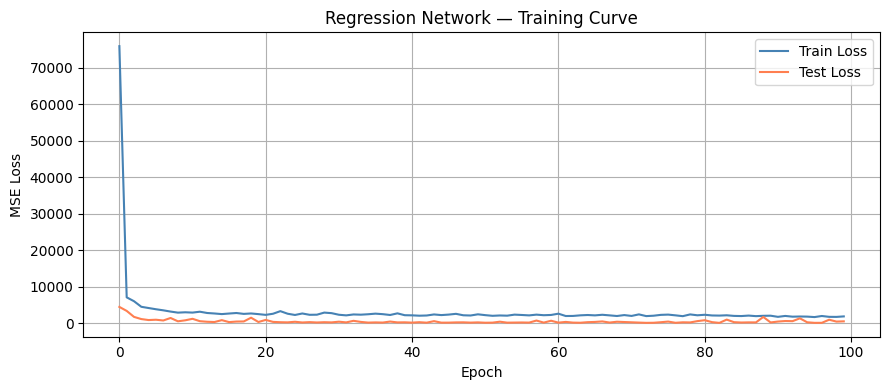

In [8]:
#(Plot Training Curve — Regression)

plt.figure(figsize=(9, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(test_losses,  label='Test Loss',  color='coral')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Regression Network — Training Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()                                 
plt.show()


In [9]:
#(Evaluate Regression)

reg_model.eval()
with torch.no_grad():
  y_pred_test  = reg_model(X_test_t).cpu().numpy()
  y_pred_train = reg_model(X_train_t).cpu().numpy()

y_reg_test_np  = y_reg_test_t.cpu().numpy()
y_reg_train_np = y_reg_train_t.cpu().numpy()

r2_train = r2_score(y_reg_train_np, y_pred_train)
r2_test  = r2_score(y_reg_test_np,  y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_reg_test_np, y_pred_test))
mae      = mean_absolute_error(y_reg_test_np, y_pred_test)

print("=== Deep Learning Regressor ===")
print(f"R² Train : {r2_train:.4f}")
print(f"R² Test  : {r2_test:.4f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAE      : {mae:.2f}")

=== Deep Learning Regressor ===
R² Train : 0.9954
R² Test  : 0.9949
RMSE     : 23.22
MAE      : 12.36


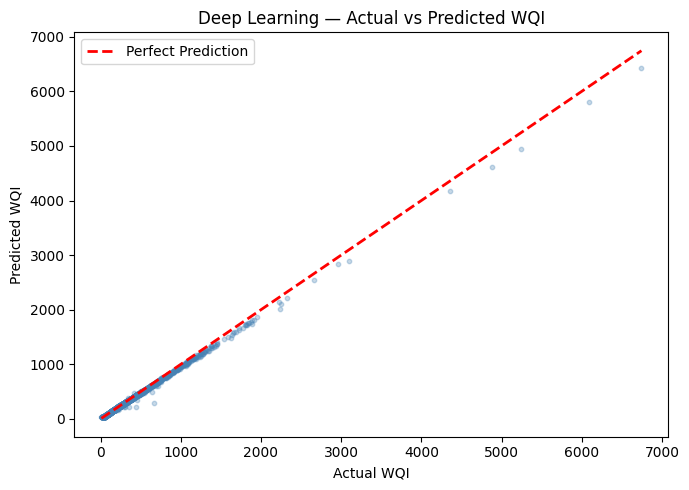

In [10]:
#(Actual vs Predicted — Regression)

plt.figure(figsize=(7, 5))
plt.scatter(y_reg_test_np, y_pred_test, alpha=0.3, color='steelblue', s=10)
plt.plot([y_reg_test_np.min(), y_reg_test_np.max()],
       [y_reg_test_np.min(), y_reg_test_np.max()],
       'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual WQI')
plt.ylabel('Predicted WQI')
plt.title('Deep Learning — Actual vs Predicted WQI')
plt.legend()
plt.tight_layout()
plt.show()


## Part 2 — Classification Network (Predict Water Quality)

### Architecture:
Input(n_features) → Dense(128) → BatchNorm → ReLU → Dropout(0.3)
               → Dense(64)  → BatchNorm → ReLU → Dropout(0.3)
               → Dense(32)  → ReLU
               → Dense(5)   → Output (5 class probabilities)

### New concepts vs Regression:
- **BatchNorm** → normalizes layer outputs during training → faster, more stable
- **CrossEntropyLoss** → loss for multi-class classification (includes softmax internally)
- Output has 5 neurons → one score per class → softmax picks the highest



In [15]:
#(Define Classification Network)

class WaterQualityClassifier(nn.Module):
  def __init__(self, input_dim, num_classes):
      super(WaterQualityClassifier, self).__init__()
      self.network = nn.Sequential(
          nn.Linear(input_dim, 128),
          nn.BatchNorm1d(128),                   
          nn.ReLU(),
          nn.Dropout(0.3),
          nn.Linear(128, 64),
          nn.BatchNorm1d(64),
          nn.ReLU(),                             
          nn.Dropout(0.3),
          nn.Linear(64, 32),
          nn.ReLU(),
          nn.Linear(32, num_classes)
      )

  def forward(self, x):
      return self.network(x)

clf_model = WaterQualityClassifier(n_features, n_classes).to(device)
print(clf_model)
print(f"\nTotal parameters: {sum(p.numel() for p in clf_model.parameters()):,}")



WaterQualityClassifier(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=5, bias=True)
  )
)

Total parameters: 14,853


In [16]:
#(Train Classification Network)

EPOCHS = 100
LR     = 0.001

criterion_clf = nn.CrossEntropyLoss()
optimizer_clf = optim.Adam(clf_model.parameters(), lr=LR)

train_losses, test_losses   = [], []
train_accs,   test_accs     = [], []

for epoch in range(EPOCHS):                        
  # Training phase
  clf_model.train()
  batch_losses, batch_accs = [], []
  for X_batch, y_batch in clf_train_loader:
      optimizer_clf.zero_grad()
      logits = clf_model(X_batch)
      loss   = criterion_clf(logits, y_batch)
      loss.backward()
      optimizer_clf.step()
      preds = logits.argmax(dim=1)               
      batch_losses.append(loss.item())
      batch_accs.append((preds == y_batch).float().mean().item())

  # Evaluation phase
  clf_model.eval()                               
  with torch.no_grad():
      test_logits = clf_model(X_test_t)
      test_loss   = criterion_clf(test_logits, y_clf_test_t).item()
      test_preds  = test_logits.argmax(dim=1)
      test_acc    = (test_preds == y_clf_test_t).float().mean().item()

  train_losses.append(np.mean(batch_losses))
  test_losses.append(test_loss)
  train_accs.append(np.mean(batch_accs))
  test_accs.append(test_acc)

  if (epoch + 1) % 10 == 0:                      
      print(f"Epoch [{epoch+1:3d}/{EPOCHS}]  "
            f"Train Loss: {np.mean(batch_losses):.4f}  "
            f"Test Loss: {test_loss:.4f}  "
            f"Train Acc: {np.mean(batch_accs):.4f}  "
            f"Test Acc: {test_acc:.4f}")



Epoch [ 10/100]  Train Loss: 0.3596  Test Loss: 0.3313  Train Acc: 0.8412  Test Acc: 0.8395
Epoch [ 20/100]  Train Loss: 0.3166  Test Loss: 0.2385  Train Acc: 0.8627  Test Acc: 0.8925
Epoch [ 30/100]  Train Loss: 0.3127  Test Loss: 0.2589  Train Acc: 0.8646  Test Acc: 0.8757
Epoch [ 40/100]  Train Loss: 0.2846  Test Loss: 0.2469  Train Acc: 0.8773  Test Acc: 0.8875
Epoch [ 50/100]  Train Loss: 0.2666  Test Loss: 0.6414  Train Acc: 0.8847  Test Acc: 0.7373
Epoch [ 60/100]  Train Loss: 0.2630  Test Loss: 0.2620  Train Acc: 0.8884  Test Acc: 0.8731
Epoch [ 70/100]  Train Loss: 0.2734  Test Loss: 0.2825  Train Acc: 0.8826  Test Acc: 0.8647
Epoch [ 80/100]  Train Loss: 0.2764  Test Loss: 0.1792  Train Acc: 0.8834  Test Acc: 0.9409
Epoch [ 90/100]  Train Loss: 0.2592  Test Loss: 0.1769  Train Acc: 0.8871  Test Acc: 0.9280
Epoch [100/100]  Train Loss: 0.2635  Test Loss: 0.4468  Train Acc: 0.8891  Test Acc: 0.7932


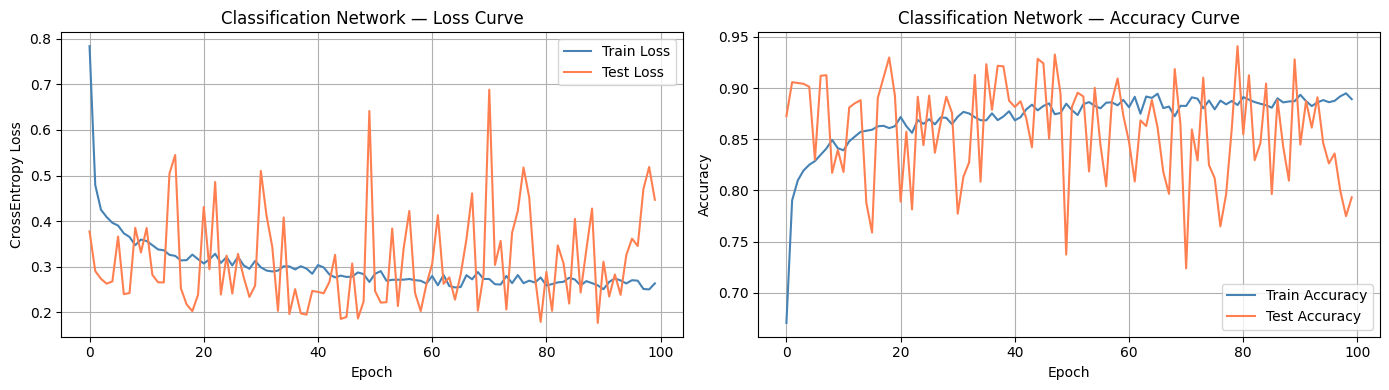

In [17]:
#(Plot Training Curves — Classification)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses, label='Train Loss', color='steelblue')
axes[0].plot(test_losses,  label='Test Loss',  color='coral')
axes[0].set_title('Classification Network — Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CrossEntropy Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_accs, label='Train Accuracy', color='steelblue')
axes[1].plot(test_accs,  label='Test Accuracy',  color='coral')
axes[1].set_title('Classification Network — Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()                                   
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [18]:
#(Evaluate Classification)

clf_model.eval()
with torch.no_grad():
  y_clf_pred_test  = clf_model(X_test_t).argmax(dim=1).cpu().numpy()
  y_clf_pred_train = clf_model(X_train_t).argmax(dim=1).cpu().numpy()

y_clf_test_np  = y_clf_test_t.cpu().numpy()
y_clf_train_np = y_clf_train_t.cpu().numpy()

acc_train = accuracy_score(y_clf_train_np, y_clf_pred_train)
acc_test  = accuracy_score(y_clf_test_np,  y_clf_pred_test)
f1_test   = f1_score(y_clf_test_np, y_clf_pred_test, average='weighted')

print("=== Deep Learning Classifier ===")
print(f"Accuracy Train : {acc_train:.4f}")
print(f"Accuracy Test  : {acc_test:.4f}")          
print(f"F1 Score Test  : {f1_test:.4f}")

print("\n=== Classification Report ===")
print(classification_report(
  y_clf_test_np,                                 
  y_clf_pred_test,
  target_names=le.classes_
))

=== Deep Learning Classifier ===
Accuracy Train : 0.7964
Accuracy Test  : 0.7932
F1 Score Test  : 0.7713

=== Classification Report ===
                         precision    recall  f1-score   support

              Excellent       1.00      0.01      0.03       136
                   Good       0.41      0.30      0.34       317
                   Poor       0.76      0.67      0.71      1066
Unsuitable for Drinking       0.95      1.00      0.97      1370
Very Poor yet Drinkable       0.70      0.92      0.80       917

               accuracy                           0.79      3806
              macro avg       0.77      0.58      0.57      3806
           weighted avg       0.79      0.79      0.77      3806



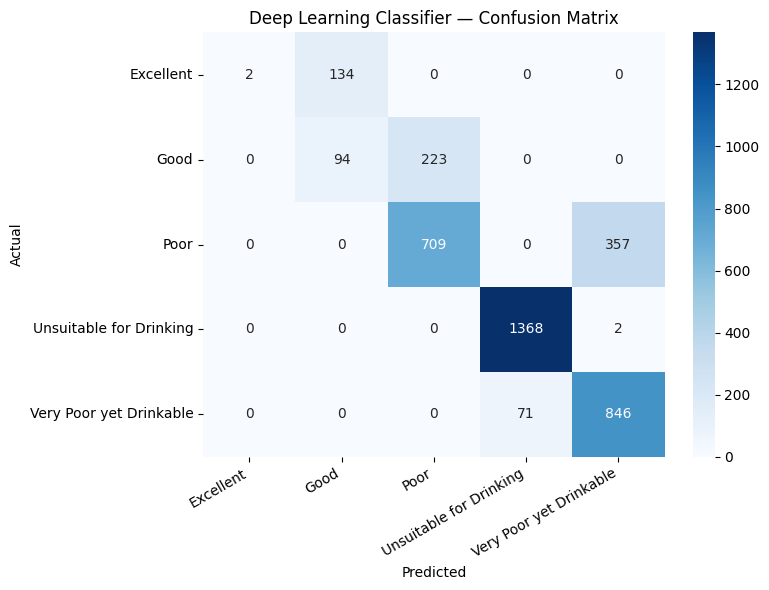

In [19]:
#(Confusion Matrix)                  

cm = confusion_matrix(y_clf_test_np, y_clf_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
          xticklabels=le.classes_,
          yticklabels=le.classes_)               
plt.title('Deep Learning Classifier — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()                                 
plt.show()


In [24]:
summary = pd.DataFrame([
  {
      'Task': 'Regression (WQI)',
      'Train Score': f"R² = {r2_train:.4f}",
      'Test Score':  f"R² = {r2_test:.4f}",
      'RMSE': round(rmse, 2),
      'MAE':  round(mae, 2)
  },
  {
      'Task': 'Classification',
      'Train Score': f"Acc = {acc_train:.4f}",
      'Test Score':  f"Acc = {acc_test:.4f}",
      'RMSE': '—',
      'MAE':  f"F1 = {f1_test:.4f}"
  }
])

summary



,Task,Train Score,Test Score,RMSE,MAE
0,Regression (WQI),R² = 0.9954,R² = 0.9949,23.22,12.36
1,Classification,Acc = 0.7964,Acc = 0.7932,—,F1 = 0.7713


In [25]:
results = {
  'DL Regression': {
      'r2_train': r2_train,
      'r2_test':  r2_test,
      'rmse':     rmse
  },
  'DL Classification': {
      'acc_train': acc_train,
      'acc_test':  acc_test,
      'f1_test':   f1_test
  }
}

with open('results_07_deep_learning.pkl', 'wb') as f:
  pickle.dump(results, f)

print("Saved. Move on to 08_Model_Comparison.ipynb")



Saved. Move on to 08_Model_Comparison.ipynb


Key things to watch:

- loss should decrease steadily — if test loss increases while train loss drops, that's overfitting
- training curves are the most important diagnostic in deep learning
- final comparison table and bar chart — this is what you submit with the assignment
- BatchNorm in Cell 12 — classifier has BatchNorm, regressor doesn't — notice if it makes training more stable
